# Test Fine-Tuned Florence-2 Model


In [1]:
import os
import torch
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor

# Thiết lập device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ID model gốc trên Hugging Face Hub (hoặc dùng 'microsoft/Florence-2-large')
model_id = 'microsoft/Florence-2-base'

# Florence-2 chạy tối ưu nhất với float16 trên GPU
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Loading base model from {model_id}...")
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    torch_dtype=torch_dtype, 
    trust_remote_code=True
).to(device)

processor = AutoProcessor.from_pretrained(
    model_id, 
    trust_remote_code=True
)

print("Model loaded successfully!")

Using device: cpu
Loading base model from microsoft/Florence-2-base...
Model loaded successfully!


In [2]:
def test_model_on_image(image_path, question):
    image = Image.open(image_path).convert("RGB")
    
    # Florence-2 yêu cầu đúng format task token: "<VQA> [câu hỏi]"
    task_prompt = "<VQA>"
    prompt = f"{task_prompt}{question}"

    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)

    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        num_beams=3
    )

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    # Dùng processor.post_process_generation để trích xuất text chuẩn
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )
    
    return parsed_answer.get(task_prompt, parsed_answer)

Starting inference on test images...

--------------------------------------------------
Processing: depositphotos360844438xl-1724808666620.jpg


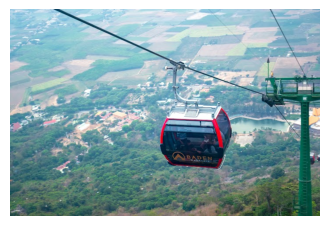

Question: Where is this place?
Answer: QA>Where is this place<loc_0><loc_0><loc_998><loc_998>
--------------------------------------------------
Processing: images.jpg


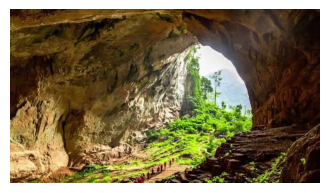

Question: Where is this place?
Answer: QA>Where is this place<loc_0><loc_0><loc_998><loc_998>
--------------------------------------------------
Processing: mu-cang-chai-1512708804.png


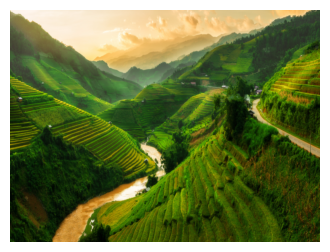

Question: Where is this place?
Answer: QA>Where is this place<loc_0><loc_0><loc_998><loc_998>
--------------------------------------------------
Processing: tuong-phat-nui-ba-den-tay-ninh-2.jpg


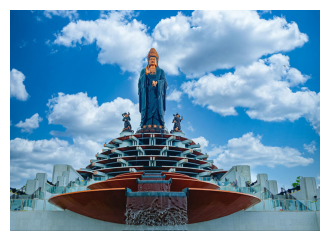

Question: Where is this place?
Answer: QA>Where is this place


In [3]:
import matplotlib.pyplot as plt

test_images_dir = './test_images'
default_question = "Where is this place?"

print("Starting inference on test images...\n")

if not os.path.exists(test_images_dir):
    print(f"Thư mục {test_images_dir} không tồn tại.")
else:
    for filename in os.listdir(test_images_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            image_path = os.path.join(test_images_dir, filename)
            print("-"*50)
            print(f"Processing: {filename}")
            
            # Hiển thị ảnh
            img = Image.open(image_path)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
            
            try:
                answer = test_model_on_image(image_path, default_question)
                print(f"Question: {default_question}")
                if isinstance(answer, dict) and '<vqa>' in answer:
                    print(f"Answer: {answer['<vqa>']}")
                else:
                    print(f"Answer: {answer}")
            except Exception as e:
                print(f"Lỗi trong quá trình xử lý {filename}: {e}")